✅ Đã lưu biểu đồ thành công: cycle_loss_curve_final.png


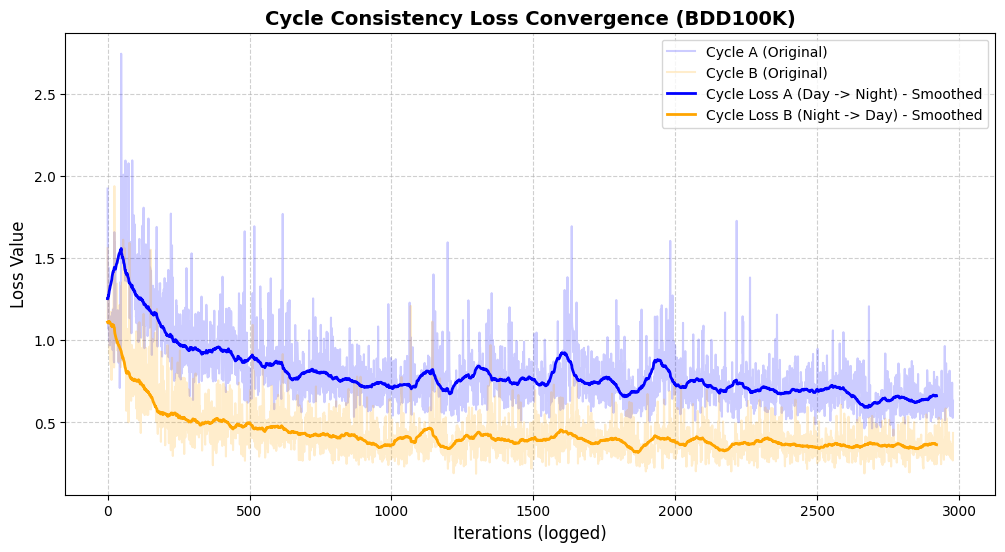

In [2]:
import matplotlib.pyplot as plt
import re
import os
import numpy as np

def plot_cycle_loss(log_path):
    epochs = []
    cycle_A = []
    cycle_B = []
    
    # Kiểm tra xem file có thực sự tồn tại không trước khi mở
    if not os.path.exists(log_path):
        print(f"❌ Không tìm thấy file tại: {log_path}")
        print("Gợi ý: Elaine thử chạy lệnh !find /workspace -name 'loss_log.txt' để check lại vị trí nhé.")
        return

    # Đọc file log
    with open(log_path, 'r') as f:
        for line in f:
            # Dùng Regex để tìm các giá trị loss trong log
            if 'cycle_A' in line:
                try:
                    # Trích xuất số Epoch và giá trị loss
                    ep_match = re.search(r'epoch: (\d+)', line)
                    cA_match = re.search(r'cycle_A: ([\d\.]+)', line)
                    cB_match = re.search(r'cycle_B: ([\d\.]+)', line)
                    
                    if ep_match and cA_match and cB_match:
                        epochs.append(int(ep_match.group(1)))
                        cycle_A.append(float(cA_match.group(1)))
                        cycle_B.append(float(cB_match.group(1)))
                except Exception as e:
                    continue

    if not cycle_A:
        print("File log trống hoặc không đúng định dạng CycleGAN.")
        return

    # Vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    
    # Vẽ đường gốc (màu nhạt)
    plt.plot(cycle_A, color='blue', alpha=0.2, label='Cycle A (Original)')
    plt.plot(cycle_B, color='orange', alpha=0.2, label='Cycle B (Original)')
    
    # Vẽ đường trung bình trượt (Moving Average) để biểu đồ mượt hơn cho báo cáo
    window = max(1, len(cycle_A) // 50) # Tự động tính cửa sổ trượt
    smooth_A = np.convolve(cycle_A, np.ones(window)/window, mode='valid')
    smooth_B = np.convolve(cycle_B, np.ones(window)/window, mode='valid')
    
    plt.plot(smooth_A, label='Cycle Loss A (Day -> Night) - Smoothed', color='blue', linewidth=2)
    plt.plot(smooth_B, label='Cycle Loss B (Night -> Day) - Smoothed', color='orange', linewidth=2)
    
    plt.title('Cycle Consistency Loss Convergence (BDD100K)', fontsize=14, fontweight='bold')
    plt.xlabel('Iterations (logged)', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Lưu biểu đồ
    save_name = 'cycle_loss_curve_final.png'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"✅ Đã lưu biểu đồ thành công: {save_name}")
    plt.show()

# --- SỬ DỤNG ĐƯỜNG DẪN TUYỆT ĐỐI ĐỂ FIX LỖI ---
path_to_log = '/workspace/pytorch-CycleGAN-and-pix2pix/checkpoints/bdd_resnet9_10ep/loss_log.txt'

plot_cycle_loss(path_to_log)